# Readme

Plot responses by type.

In [3]:
import os

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [4]:
data_folder = "../../data/preprocessed-data"

df_rois = pd.concat([pd.read_hdf(os.path.join(data_folder, f'df_eyewire2_roi_level_GCL{i}.h5'), key='dataframe') for i in range(5)])

# Plot function

In [5]:
def plot_mean_and_sd(ax, traces, time, color='black', alt_color='dimgray', facealpha=0.2, offset=0.0):
    if traces.shape[0] <= 2:
        ax.plot(time, traces[0] - np.mean(traces[0]) + offset, color=color)
        if len(traces) == 2:
            ax.plot(time, traces[1] - np.mean(traces[1]) + offset, color=alt_color)
    else:
        mu = np.mean(traces, axis=0)
        mu = mu - np.mean(mu) + offset
        sd = np.std(traces, axis=0)

        ax.plot(time, mu, color=color)
        ax.fill_between(time, mu - sd, mu + sd, color=color, alpha=facealpha)

In [7]:
swc_dir = 'Z:/SharedFiles/Eyewire2/morphologies-ew2/c6fb66deed2b53502e41fdcec0caa3b9'
swc_files = [f for f in os.listdir(swc_dir) if f.endswith('.swc')]

In [8]:
morph_folder = "../../data/morphological-data"
morph_spreadsheet_filename = "Eyewire II Proofread Cells Master List - All Cells 2025-09-09.csv"

df_master = pd.read_csv(os.path.join(os.path.join(morph_folder, morph_spreadsheet_filename)), dtype=str)

nuc_col_master = 'Updated Nuc ID (Sept 2)'
seg_col_master = 'Updated Seg ID (Sept 2)'
assert seg_col_master in df_master.columns, f"Column '{seg_col_master}' not found in df_master"
assert nuc_col_master in df_master.columns, f"Column '{nuc_col_master}' not found in df_master"

print(df_master.shape)
df_master.head()

(8687, 35)


,Index,Nuc Coords,Soma Coords,Cell Type (deprecated),611 Proofreader,Proofreader 2,Status,AIS annotated?,Final Link,Final NucID,...,Machine soma location,Additional Notes,Index OK?,Index for sanity check,Updated Nuc ID (Sept 2),Updated Seg ID (Sept 2),Cell Requires Review (DO NOT use Updated IDs for those cells),Review complete,Review notes,Cutoff Severity for Status=Complete (cut off) cells (%Hits Edge & Can't Fix Annotations in Proofreading link)
0,A4,NaN,NaN,OFF-SAC,Roden Rey,NaN,Complete (cut off),NaN,https://spelunker.cave-explorer.org/#!middleau...,NaN,...,INL,NaN,ok,A4,NaN,NaN,FALSE,NaN,NaN,NaN
1,A5,NaN,NaN,OFF-SAC,Christine,NaN,Complete (cut off),NaN,https://spelunker.cave-explorer.org/#!middleau...,NaN,...,INL,NaN,ok,A5,NaN,NaN,FALSE,NaN,NaN,NaN
2,A7,"63573, 49070, 1720","63537, 49048, 1697",OFF-SAC,April Grace,NaN,Complete,NaN,https://spelunker.cave-explorer.org/#!middleau...,720575940545056597,...,INL,NaN,ok,A7,720575940545056597,720575940572159335,FALSE,NaN,NaN,NaN
3,A11,"50561, 64354, 1734","50520, 64370, 1656",OFF-SAC,Roden Rey,NaN,Complete,NaN,https://spelunker.cave-explorer.org/#!middleau...,720575940544186175,...,INL,NaN,ok,A11,720575940544186175,720575940563309953,FALSE,NaN,NaN,NaN
4,A12,NaN,NaN,OFF-SAC,Roden Rey,NaN,Complete (cut off),NaN,https://spelunker.cave-explorer.org/#!middleau...,NaN,...,INL,NaN,ok,A12,NaN,NaN,FALSE,NaN,NaN,NaN


In [9]:
df_merged = pd.merge(
    df_master.set_index(nuc_col_master),
    df_rois.set_index(df_rois['nuc_id'].astype(str)),
    left_index=True, right_index=True, how='inner'
).reset_index()

print(df_merged.shape)
df_merged.head()

(379, 105)


,Updated Nuc ID (Sept 2),Index,Nuc Coords,Soma Coords,Cell Type (deprecated),611 Proofreader,Proofreader 2,Status,AIS annotated?,Final Link,...,cluster_id,group_id,supergroup,prob_cluster,prob_group,prob_supergroup,prob_class,probs_per_cluster,seg_id,nuc_id
0,720575940577751704,D1,"32653.0,23923.0,553.0","32653.0,23923.0,583.0",NaN,Elison,Greg,Complete,Annotated,https://spelunker.cave-explorer.org/#!middleau...,...,18,12,ON-OFF,0.804667,0.819760,0.832646,0.913740,"[0.0020822615335256726, 0.0032838992937911002,...",720575940550529705,720575940577751704
1,720575940534317101,D2,"33159.0,22959.0,606.0","33159.0,22959.0,661.0",NaN,Juliane,Jonathan,Complete,Annotated,https://spelunker.cave-explorer.org/#!middleau...,...,51,34,dAC,0.605752,0.615440,0.702638,0.702638,"[0.003336756586838654, 0.008818983121221289, 0...",720575940568652126,720575940534317101
2,720575940554891618,D3,"33787.0,21853.0,597.0","33787.0,21853.0,677.0",ON-SAC,Nseraf,Juliane,Complete,AC,https://spelunker.cave-explorer.org/#!middleau...,...,68,42,dAC,0.772927,0.790771,0.927322,0.927322,"[0.0017071109567420337, 0.0016375104799094017,...",720575940572885792,720575940554891618
3,720575940554657378,D4,"34131.0,21306.0,627.0","34131.0,21306.0,657.0",NaN,Christine,NaN,Complete,AC,https://spelunker.cave-explorer.org/#!middleau...,...,74,46,dAC,0.488712,0.494132,0.803859,0.803859,"[0.0028589256378742686, 0.003341772704406851, ...",720575940566222700,720575940554657378
4,720575940571117757,D5,"34753.0,20187.0,669.0","34753.0,20187.0,684.0",NaN,Glenda,Greg,Complete,NaN,https://spelunker.cave-explorer.org/#!middleau...,...,38,28,Slow ON,0.580714,0.581366,0.590559,0.629739,"[0.0012246466912174362, 0.0011384551512382875,...",720575940577371948,720575940571117757


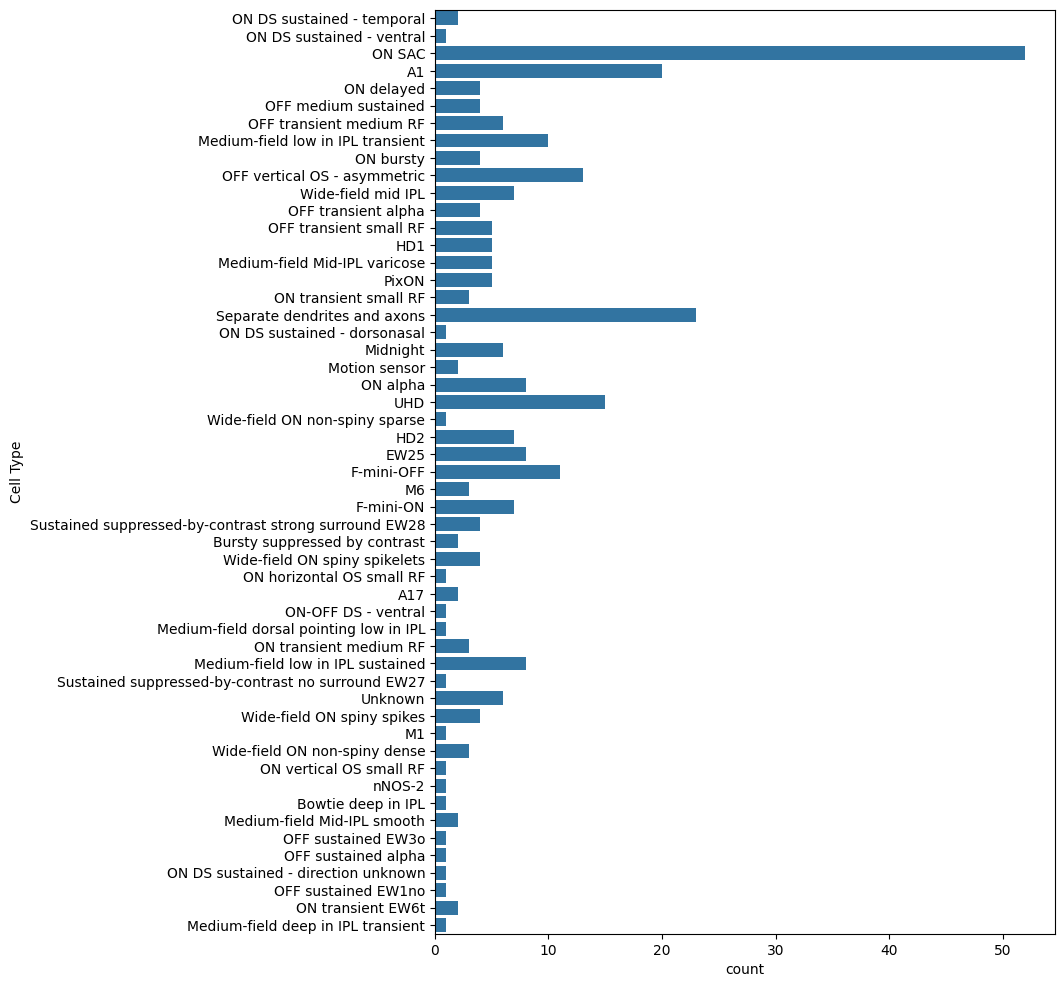

In [10]:
import seaborn as sns

fig, ax = plt.subplots(1, 1, figsize=(8, 12))
sns.countplot(ax=ax, data=df_merged, y='Cell Type')
plt.show()

In [11]:
# DSI / OSI from djimaging

MB_DIRS = (0, 180, 45, 225, 90, 270, 135, 315)


def get_dir_idx(snippets, dir_order=MB_DIRS):
    """
    snippets: np.ndarray (times, dirs*reps)
    dir_order: np.ndarray (dirs, ) or (dirs*reps, )
    """
    dir_order = np.asarray(dir_order).squeeze()
    assert dir_order.ndim == 1, dir_order.shape
    assert snippets.ndim == 2, snippets.shape
    n_snippets = snippets.shape[-1]
    assert (n_snippets % dir_order.size) == 0, f"Snippet length {n_snippets} is not a multiple of {dir_order.size}"
    dir_order = np.tile(dir_order, n_snippets // dir_order.size)
    assert n_snippets == dir_order.size

    dir_deg = dir_order[:8]  # get the directions of the bars in degree
    dir_rad = np.deg2rad(dir_deg)  # convert to radians
    dir_idx = [list(np.where(dir_order == d)[0]) for d in dir_deg]

    return dir_idx, dir_rad


def sort_response_matrix(snippets: np.ndarray, idxs: list, directions: np.ndarray):
    """
    Sorts the snippets according to stimulus condition and repetition into a time x direction x repetition matrix
    Inputs:
    snippets    list or array, time x (directions*repetitions)
    idxs        list of lists giving idxs into last axis of snippets. idxs[0] gives the indexes of rows in snippets
                which are responses to the direction directions[0]
    Outputs:
    sorted_responses   array, time x direction x repetitions, with directions sorted(!) (0, 45, 90, ..., 315) degrees
    sorted_directions   array, sorted directions
    """
    structured_responses = snippets[:, idxs]
    sorting = np.argsort(directions)
    sorted_responses = structured_responses[:, sorting, :]
    sorted_directions = directions[sorting]
    return sorted_responses, sorted_directions


def preprocess_mb_snippets(snippets, dir_order=MB_DIRS):
    dir_idx, dir_rad = get_dir_idx(snippets, dir_order)

    sorted_responses, sorted_directions = sort_response_matrix(snippets, dir_idx, dir_rad)
    sorted_averages = np.mean(sorted_responses, axis=-1)
    return sorted_directions, sorted_responses, sorted_averages


def get_time_dir_kernels(sorted_responses: np.ndarray, dt: float):
    """
    Performs singular value decomposition on the time x direction matrix (averaged across repetitions)
    Uses a heuristic to try to determine whether a sign flip occurred during svd
    For the time course, the mean of the first second is subtracted and then the vector is divided by the maximum
    absolute value.
    For the direction/orientation tuning curve, the vector is normalized to the range (0,1)

    Parameters:
    sorted_responses (array): Time x direction matrix.
    dt (float): 1 / sampling_rate of trace.

    Returns:
    tuple: Contains time_kernel (array, time x 1), direction_tuning (array, directions x 1), and singular_value (float).
    """
    U, S, Vh = np.linalg.svd(sorted_responses)

    time_component = U[:, 0]
    dir_component = Vh[0, :]

    # the time_kernel determined by SVD should be correlated to the average response across all directions. if the
    # correlation is negative, U is likely flipped

    if np.mean((-1 * time_component - np.mean(sorted_responses, axis=-1)) ** 2) < np.mean(
            (time_component - np.mean(sorted_responses, axis=-1)) ** 2
    ):
        su = -1
    else:
        su = 1

    sv = np.sign(np.mean(np.sign(dir_component)))
    if sv == 1 and su == 1:
        s = 1
    elif sv == -1 and su == -1:
        s = -1
    elif sv == 1 and su == -1:
        s = 1
    elif sv == 0:
        s = su
    else:
        s = 1

    time_component *= s
    dir_component *= s

    # determine which entries correspond to the first second, assuming 4 seconds presentation time
    first_second_idx = np.maximum(int(np.floor(1.0 / dt)), 1)
    time_component -= np.mean(time_component[:first_second_idx])
    time_component = time_component / np.max(np.abs(time_component))

    #dir_component -= np.min(dir_component)
    #dir_component = dir_component / np.max(dir_component)

    return time_component, dir_component

In [12]:
t_chirp = np.arange(df_merged.chirp_average_norm.iloc[0].size) * df_merged.chirp_average_dt.iloc[0]
t_bar = np.arange(df_merged.bar_time_component.iloc[0].size) * df_merged.bar_snippets_dt.iloc[0]

In [13]:
import skeliner as sk


def plot_chirp(ax, row):
    snippets = row['chirp_snippets']
    for i, trace in enumerate(snippets.T):
        ax.plot(np.arange(0, len(trace)) * row['chirp_snippets_dt'], trace / np.max(np.abs(trace)), color='dimgray',
                alpha=0.5)
    ax.plot(np.arange(0, len(row['chirp_average_norm'])) * row['chirp_average_dt'], row['chirp_average_norm'],
            color='darkred', alpha=0.8)
    #ax.axhline(0, c='dimgray', ls='--')
    #for t in [2, 5, 8, 30]:
    #   ax.axvline(t, c='dimgray', ls='--')


def plot_bar(ax, row, annotate_dirs=False):
    for i, dir in enumerate(MB_DIRS):
        snippets = row['bar_snippets'][:, np.array([0, 8, 16]) + i]
        time = (np.arange(0, snippets.shape[0]) + (snippets.shape[0] * 1.2 * i)) * row['bar_snippets_dt']
        for trace in snippets.T:
            ax.plot(time, trace, color='dimgray', alpha=0.5)
        ax.plot(time, np.mean(snippets, axis=1), color='darkred', alpha=0.8)
        ax.axhline(0, c='dimgray', ls='--')
        if annotate_dirs:
            ax.text(time[0] + 0.5 * (time[-1] - time[0]), np.max(row['bar_snippets']) + 0.1, f'{dir}°',
                    ha='center', va='top', fontsize=8)


def plot_bar_dir(ax, row):
    if np.any(~np.isfinite(row['bar_snippets'])):
        raise ValueError('bar_snippets not finite')

    sorted_directions, sorted_responses, sorted_averages = preprocess_mb_snippets(snippets=row['bar_snippets'])
    time_component, dir_component = get_time_dir_kernels(sorted_averages, dt=row['bar_snippets_dt'])
    sorted_directions = np.append(sorted_directions, sorted_directions[0])
    dir_component = np.append(dir_component, dir_component[0])

    if np.any(~np.isfinite(dir_component)):
        raise ValueError('dir_component not finite')

    ax.plot(sorted_directions, np.clip(dir_component, 0, None), color='darkred', alpha=0.8, lw=2)
    ax.xaxis.set_tick_params(pad=-20)


def plot_morph(ax, row):
    sk.plot.projection(row.skel, ax=ax, plane='xy')  #, color_by="ntype", skel_cmap='Grays')
    sx, sy, sz = row.skel.soma.center

    ax.set_xlim(sx - 200, sx + 200)

    ax.set_ylim(sy - 200, sy + 200)

In [14]:
def add_skels(df):
    df = df.copy()

    df['swc_path'] = df[seg_col_master].apply(lambda x: os.path.join(swc_dir, f"{x}.swc"))
    df['swc_exists'] = df['swc_path'].apply(lambda x: os.path.isfile(x))
    if np.any(~df['swc_exists']):
        print('SWC not found:', df[~df['swc_exists']].swc_path)
    df = df[df['swc_exists']]
    df['skel'] = df['swc_path'].apply(lambda x: sk.io.load_swc(x))
    return df

def plot_cells(df):
    assert df.shape[0] > 0, "No data to plot"
    df = add_skels(df)

    fig, axs = plt.subplots(len(df), 4, figsize=(8, len(df) * 1.2), width_ratios=(1, 2, 2, 1))

    for i, ax_to_replace in enumerate(axs[:, -1]):
        ax_to_replace.remove()
        polar_ax = fig.add_subplot(ax_to_replace.get_subplotspec(), polar=True)
        axs[i, -1] = polar_ax

    for i, (seg_id, row) in enumerate(df.iterrows()):
        plot_morph(ax=axs[i, 0], row=row)
        plot_chirp(ax=axs[i, 1], row=row)
        plot_bar(ax=axs[i, 2], row=row, annotate_dirs=i == 0)
        plot_bar_dir(ax=axs[i, 3], row=row)

    for ax in axs[:, :-1].flat:
        ax.set(xlabel=None, ylabel=None, xticks=[], yticks=[])
        ax.axis('off')

    for ax in axs[:, -1].flat:
        ax.set(xlabel=None, ylabel=None, xticks=np.deg2rad([0, 90, 180, 270]), yticks=[], ylim=(0, None))

    plt.tight_layout()
    return fig, axs

In [15]:
import cell_mosaics

def plot_mosaic(df, extent = (350, 1000, 0, 650)):
    assert df.shape[0] > 0, "No data to plot"
    df = add_skels(df)

    mapper = cell_mosaics.CoverageDensityMapper(field_bounds=extent, resolution=500)
    for i, (seg_id, row) in enumerate(df.iterrows()):
        mapper.add_convex_hull(row.skel.nodes[row.skel.nodes[:, 2] > -10, :2])
    fig, ax, im = mapper.plot_coverage(colormap='bone_r', plot_cell_outlines=True)
    for i, (seg_id, row) in enumerate(df.sample(1).iterrows()):
        plot_morph(ax=ax, row=row)
    ax.set(xlim=extent[:2], ylim=extent[2:])
    return fig, ax

In [144]:
fig2_dir = './figures/examples'
os.makedirs(fig2_dir, exist_ok=True)

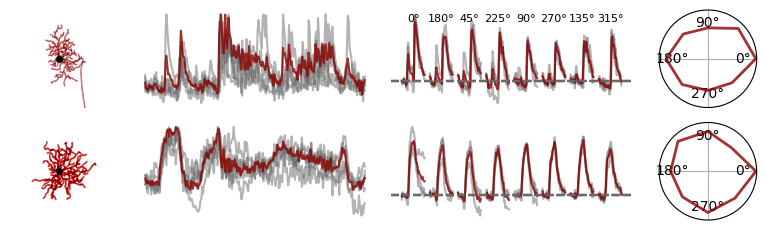

In [14]:
# For Sebastian
df_type = df_merged[
    (df_merged['roi_id'].astype(int).isin([62, 52]))
    & (df_merged["field"] == 'GCL2')
    ]
df_type = df_type.drop_duplicates(subset=[seg_col_master], keep='first')

fig, axs = plot_cells(df_type)
#plt.savefig(os.path.join(fig2_dir, 'examples_GCL2_52_62.eps'))
plt.show()

[720575940563265819 720575940572551485 720575940576369093
 720575940562015742 720575940546061452 720575940583667923
 720575940551647474 720575940547919816 720575940576381125
 720575940561194713 720575940579488144 720575940560950763]


,Updated Seg ID (Sept 2),Cell Type,Machine label
45,720575940563265819,UHD,5ti
50,720575940572551485,UHD,5ti
54,720575940576369093,UHD,5ti
90,720575940562015742,UHD,5ti
96,720575940546061452,UHD,5ti
105,720575940583667923,UHD,5ti
151,720575940551647474,UHD,5ti
164,720575940547919816,UHD,5ti
168,720575940576381125,UHD,5ti
186,720575940561194713,UHD,5ti


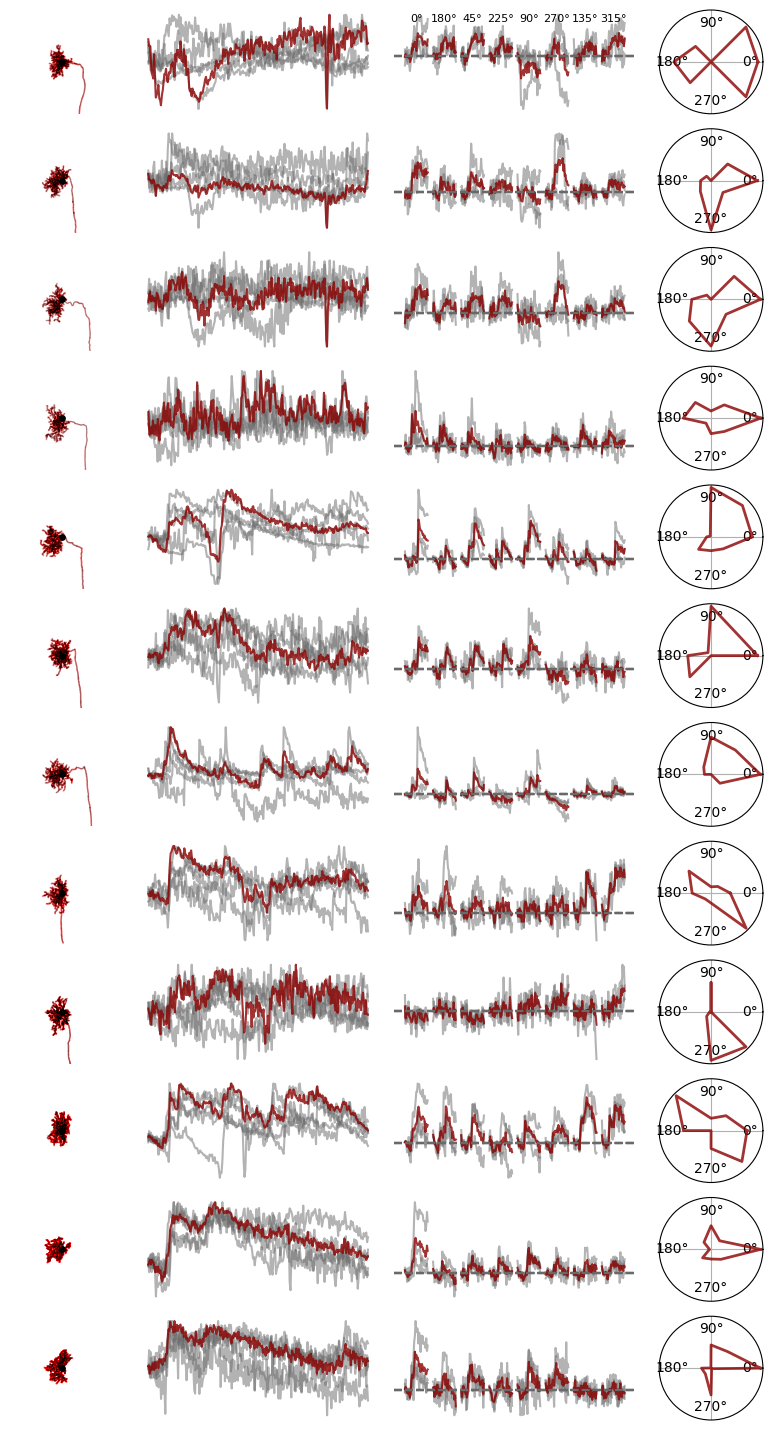

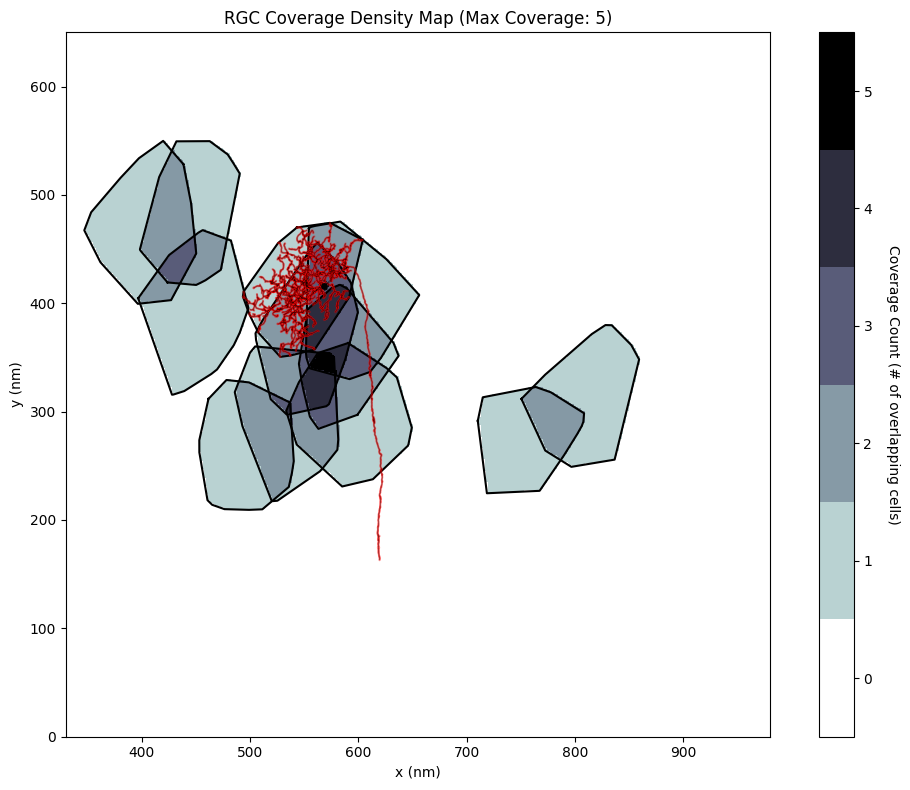

In [15]:
uhd_list = [720575940546061452, 720575940547919816, 720575940551647474, 720575940560950763, 720575940561194713,
            720575940562015742, 720575940563265819, 720575940572551485, 720575940576369093,
            720575940576381125, 720575940579488144, 720575940583667923]

df_type = df_merged[
    #((df_merged['Cell Type'] == 'UHD') | ((df_merged['Machine label'] == '5ti') & (df_merged['Confidence machine label'].astype(float) > 0.5)))
    (df_merged[seg_col_master].astype(int).isin(uhd_list))
    & ((df_merged.chirp_qidx > 0.45) | (df_merged.bar_qidx > 0.6))
    & (df_merged["Status"] == 'Complete')
    ]
df_type = df_type.drop_duplicates(subset=[seg_col_master], keep='first')

print(df_type[seg_col_master].values.astype(int))
display(df_type[[seg_col_master, 'Cell Type', 'Machine label']])

fig, axs = plot_cells(df_type)
#plt.savefig(os.path.join(fig2_dir, 'examples_uhd.pdf'))
plt.show()

fig, ax = plot_mosaic(df_type, extent = (330, 980, 0, 650))
#plt.savefig(os.path.join(fig2_dir, 'mosaic_uhd.pdf'))
plt.show()

[720575940563265819 720575940572551485 720575940576369093
 720575940562015742 720575940546061452 720575940583667923
 720575940551647474 720575940547919816 720575940576381125
 720575940561194713 720575940579488144 720575940560950763]


,Updated Seg ID (Sept 2),Cell Type,Machine label
45,720575940563265819,UHD,5ti
50,720575940572551485,UHD,5ti
54,720575940576369093,UHD,5ti
90,720575940562015742,UHD,5ti
96,720575940546061452,UHD,5ti
105,720575940583667923,UHD,5ti
151,720575940551647474,UHD,5ti
164,720575940547919816,UHD,5ti
168,720575940576381125,UHD,5ti
186,720575940561194713,UHD,5ti


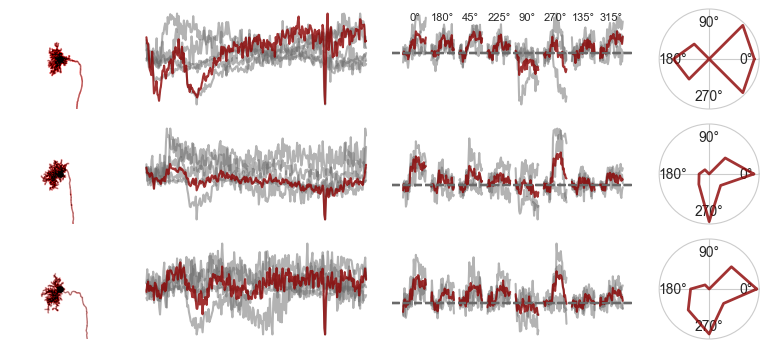

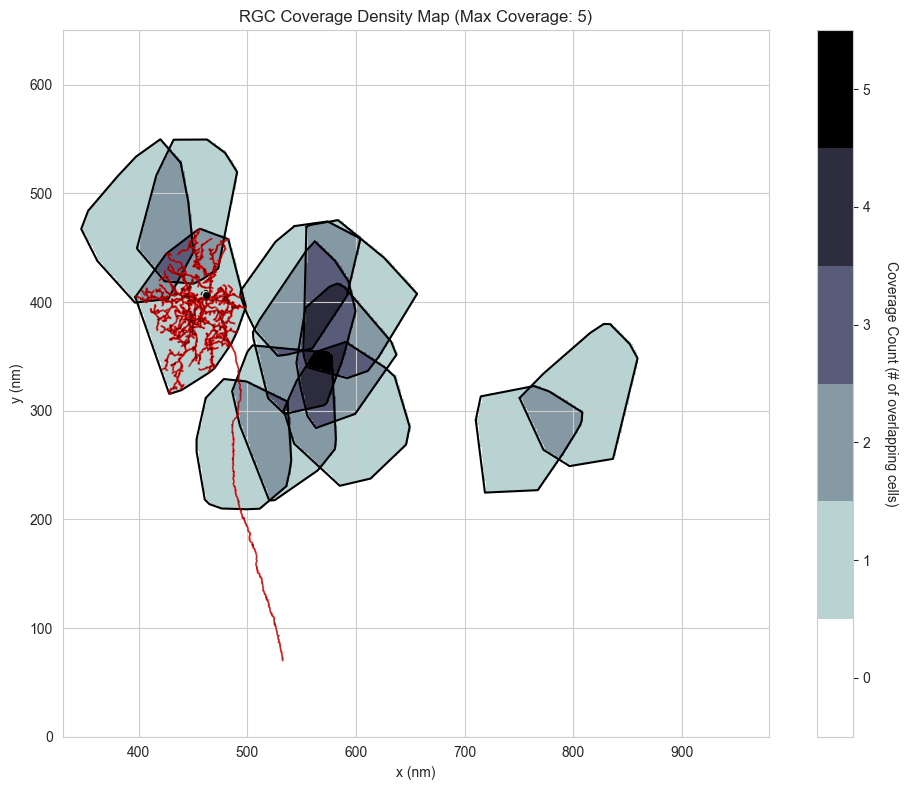

In [30]:
uhd_list = [720575940546061452, 720575940547919816, 720575940551647474, 720575940560950763, 720575940561194713,
            720575940562015742, 720575940563265819, 720575940572551485, 720575940576369093,
            720575940576381125, 720575940579488144, 720575940583667923]

df_type = df_merged[
    #((df_merged['Cell Type'] == 'UHD') | ((df_merged['Machine label'] == '5ti') & (df_merged['Confidence machine label'].astype(float) > 0.5)))
    (df_merged[seg_col_master].astype(int).isin(uhd_list))
    & ((df_merged.chirp_qidx > 0.45) | (df_merged.bar_qidx > 0.6))
    & (df_merged["Status"] == 'Complete')
    ]
df_type = df_type.drop_duplicates(subset=[seg_col_master], keep='first')

print(df_type[seg_col_master].values.astype(int))
display(df_type[[seg_col_master, 'Cell Type', 'Machine label']])

fig, axs = plot_cells(df_type.iloc[:3])
plt.savefig(os.path.join(fig2_dir, 'examples_uhd.png'), dpi=600)
plt.show()

fig, ax = plot_mosaic(df_type, extent = (330, 980, 0, 650))
plt.savefig(os.path.join(fig2_dir, 'mosaic_uhd.pdf'))
plt.show()

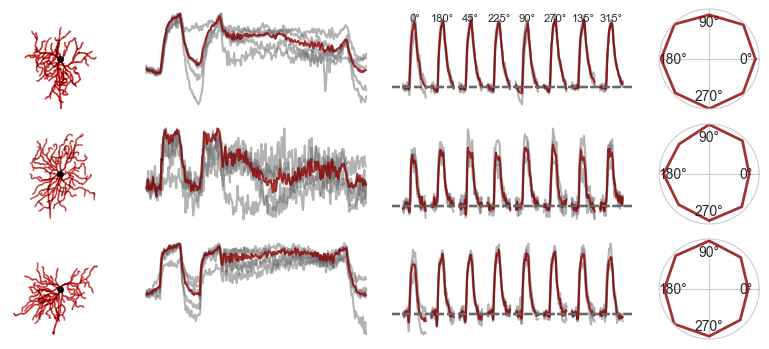

In [31]:
son_alpha_list = [720575940557469707, 720575940562911131, 720575940572157287, 720575940575066105]

df_type = df_merged[
    (df_merged[seg_col_master].astype(int).isin(son_alpha_list))
    & ((df_merged.chirp_qidx > 0.45) | (df_merged.bar_qidx > 0.6))
    & (df_merged["Status"] == 'Complete')
    ]

fig, axs = plot_cells(df_type.iloc[[0, 1, 3]])
plt.savefig(os.path.join(fig2_dir, 'examples_son_alphas.png'), dpi=600)

[720575940563567973 720575940576092590 720575940581355463
 720575940563588453]


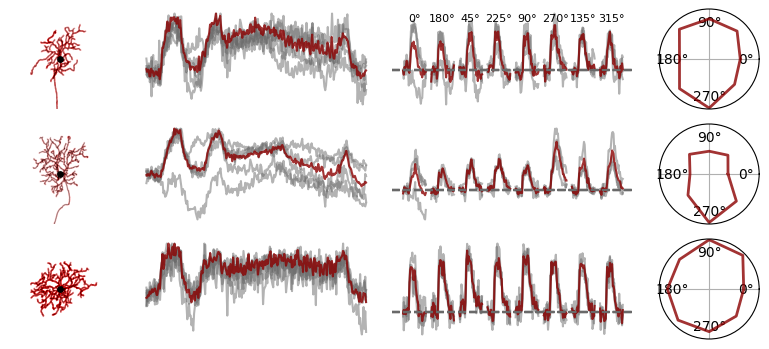

In [16]:
pixon_list = [720575940563567973, 720575940563588453, 720575940576092590, 720575940581355463]

df_type = df_merged[
    ((df_merged['Cell Type'] == 'PixON') | (
            (df_merged['Machine label'] == '9n') & (df_merged['Confidence machine label'].astype(float) > 0.5)))
    #(df_merged[seg_col_master].astype(int).isin(pixon_list))
    & ((df_merged.chirp_qidx > 0.45) | (df_merged.bar_qidx > 0.6))
    & (df_merged["Status"] == 'Complete')
    ]
df_type = df_type.drop_duplicates(subset=[seg_col_master], keep='first')

print(df_type[seg_col_master].values.astype(int))

fig, axs = plot_cells(df_type.iloc[[0, 1, 3]])
#plt.savefig(os.path.join(fig2_dir, 'examples_pixon.png'), dpi=600)

In [17]:
df_type.iloc[[0, 1, 3]]

,Updated Nuc ID (Sept 2),Index,Nuc Coords,Soma Coords,Cell Type (deprecated),611 Proofreader,Proofreader 2,Status,AIS annotated?,Final Link,...,cluster_id,group_id,supergroup,prob_cluster,prob_group,prob_supergroup,prob_class,probs_per_cluster,seg_id,nuc_id
31,720575940574221509,D30,"36884.0,20356.0,722.0","36884.0,20356.0,727.0",NaN,Elison,NaN,Complete,Annotated,https://spelunker.cave-explorer.org/#!middleau...,...,33,23,Slow ON,0.700664,0.700664,0.857186,0.919846,"[0.001954173609060556, 0.0018432415551910435, ...",720575940563567973,720575940574221509
42,720575940570684617,D39,"34836.0,25248.0,379.0","34836.0,25248.0,404.0",NaN,Rey Mark,NaN,Complete,Annotated,https://spelunker.cave-explorer.org/#!middleau...,...,65,42,dAC,0.516307,0.652191,0.747058,0.747058,"[0.0038852233741945644, 0.0032334072669986903,...",720575940576092590,720575940570684617
377,720575940569319349,D370,"51502.0,19497.0,965.0","51431.0,19511.0,994.0",NaN,Glenda,NaN,Complete,Annotated,https://spelunker.cave-explorer.org/#!middleau...,...,33,23,Slow ON,0.657267,0.657267,0.912382,0.957618,"[0.0013527515503129882, 0.001395631364001735, ...",720575940563588453,720575940569319349


# Finalize figure

In [16]:
import warnings
warnings.filterwarnings(
    "ignore",
    message=".*not compatible with tight_layout.*",
    category=UserWarning,
    module="matplotlib"
)

In [148]:
son_alpha_list = [720575940557469707, 720575940562911131, 720575940572157287, 720575940575066105]
df_type = df_merged[
    (df_merged[seg_col_master].astype(int).isin(son_alpha_list))
    & ((df_merged.chirp_qidx > 0.45) | (df_merged.bar_qidx > 0.6))
    & (df_merged["Status"] == 'Complete')]

df_son = df_type.iloc[[0, 1, 3]].copy()

In [149]:
pixon_list = [720575940563567973, 720575940563588453, 720575940576092590, 720575940581355463]
df_type = df_merged[
    ((df_merged['Cell Type'] == 'PixON') | (
            (df_merged['Machine label'] == '9n') & (df_merged['Confidence machine label'].astype(float) > 0.5)))
    #(df_merged[seg_col_master].astype(int).isin(pixon_list))
    & ((df_merged.chirp_qidx > 0.45) | (df_merged.bar_qidx > 0.6))
    & (df_merged["Status"] == 'Complete')
    ]
df_type = df_type.drop_duplicates(subset=[seg_col_master], keep='first')

df_pixon = df_type.iloc[[0, 1, 3]].copy()

In [150]:
uhd_list = [720575940546061452, 720575940547919816, 720575940551647474, 720575940560950763, 720575940561194713,
            720575940562015742, 720575940563265819, 720575940572551485, 720575940576369093,
            720575940576381125, 720575940579488144, 720575940583667923]

df_type = df_merged[
    #((df_merged['Cell Type'] == 'UHD') | ((df_merged['Machine label'] == '5ti') & (df_merged['Confidence machine label'].astype(float) > 0.5)))
    (df_merged[seg_col_master].astype(int).isin(uhd_list))
    & ((df_merged.chirp_qidx > 0.45) | (df_merged.bar_qidx > 0.6))
    & (df_merged["Status"] == 'Complete')
    ]
df_type = df_type.drop_duplicates(subset=[seg_col_master], keep='first')

df_uhd = df_type.iloc[[0, 1, 3]].copy()

In [19]:
MB_DIRS_SYMBOLS = ('\u2192', '\u2190', '\u2197', '\u2199', '\u2191', '\u2193', '\u2196', '\u2198')

In [98]:
import matplotlib.transforms as mtransforms
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm

def plot_chirp(ax, row):
    snippets = row['chirp_snippets']
    for i, trace in enumerate(snippets.T):
        ax.plot(np.arange(0, len(trace)) * row['chirp_snippets_dt'], trace / np.max(np.abs(trace)), color='dimgray',
                alpha=0.5)
    ax.plot(np.arange(0, len(row['chirp_average_norm'])) * row['chirp_average_dt'], row['chirp_average_norm'],
            color='darkred', alpha=0.8)
    #ax.axhline(0, c='dimgray', ls='--')
    #for t in [2, 5, 8, 30]:
    #   ax.axvline(t, c='dimgray', ls='--')


def plot_bar(ax, row, annotate_dirs=False):
    #for i, dir in enumerate(MB_DIRS):
    for i, dir in enumerate(MB_DIRS_SYMBOLS):
        snippets = row['bar_snippets'][:, np.array([0, 8, 16]) + i]
        time = (np.arange(0, snippets.shape[0]) + (snippets.shape[0] * 1.2 * i)) * row['bar_snippets_dt']
        for trace in snippets.T:
            ax.plot(time, trace, color='dimgray', alpha=0.5)
        ax.plot(time, np.mean(snippets, axis=1), color='darkred', alpha=0.8)
        ax.axhline(0, c='dimgray', ls='--')
        if annotate_dirs:
            #ax.text(time[0] + 0.5 * (time[-1] - time[0]), np.max(row['bar_snippets']) + 0.1, f'{dir}°',
            #        ha='center', va='top', fontsize=8)

            x = time[0] + 0.5 * (time[-1] - time[0])
            y_max = np.max(row['bar_snippets'])
            y = y_max + 0.15 * (np.max(row['bar_snippets']) - np.min(row['bar_snippets']))  # relative offset
            ax.text(
                x, y, MB_DIRS_SYMBOLS[i],
                ha='center', va='top',
                fontsize=14,
                fontweight='bold'
        )


def plot_bar_dir(ax, row):
    if np.any(~np.isfinite(row['bar_snippets'])):
        raise ValueError('bar_snippets not finite')

    sorted_directions, sorted_responses, sorted_averages = preprocess_mb_snippets(snippets=row['bar_snippets'])
    time_component, dir_component = get_time_dir_kernels(sorted_averages, dt=row['bar_snippets_dt'])
    sorted_directions = np.append(sorted_directions, sorted_directions[0])
    dir_component = np.append(dir_component, dir_component[0])

    if np.any(~np.isfinite(dir_component)):
        raise ValueError('dir_component not finite')

    ax.plot(sorted_directions, np.clip(dir_component, 0, None), color='darkred', alpha=0.8, lw=2)
    ax.xaxis.set_tick_params(pad=-20)


def plot_morph(ax, row):
    sk.plot.projection(row.skel, ax=ax, plane='xy')  #, color_by="ntype", skel_cmap='Grays')
    sx, sy, sz = row.skel.soma.center

    ax.set_xlim(sx - 200, sx + 200)
    ax.set_ylim(sy - 200, sy + 200)


def draw_scale_bar(ax, length_data, label="2 mm",
                   where="lower center",
                   y_frac=0.06, x_pad_axes=0.0,    # x pad as fraction of axis width
                   lw=1.5, fontsize=8, label_above=False):
    xlo, xhi = ax.get_xlim()
    xspan = xhi - xlo
    if xspan == 0:
        return None
    w_frac = length_data / xspan  # width of bar in axes fraction

    if where == "lower left":
        x0_frac = x_pad_axes
    elif where == "lower right":
        x0_frac = 1.0 - x_pad_axes - w_frac
    elif where == "lower center":
        x0_frac = 0.5 - w_frac / 2
    else:
        raise ValueError("where must be 'lower left' | 'lower center' | 'lower right'.")

    x1_frac = x0_frac + w_frac
    line = ax.plot([x0_frac, x1_frac], [y_frac, y_frac],
                   transform=ax.transAxes, color='k', lw=lw,
                   solid_capstyle='butt', clip_on=False, zorder=10)[0]
    dy_pts = 4 if not label_above else -4
    va = 'top' if not label_above else 'bottom'
    ax.annotate(label, xy=((x0_frac + x1_frac)/2, y_frac), xycoords=ax.transAxes,
                xytext=(0, -dy_pts), textcoords='offset points',
                ha='center', va=va, fontsize=fontsize, color='k',
                zorder=11, clip_on=False)
    return line

In [99]:
png_path = "C:/Users/Dominic Gonschorek/Documents/GitHub/eyewire2-functional-analysis/data/stimuli/chirp.png"   # <- change this
chirp_img = plt.imread(png_path) 

png_path = "C:/Users/Dominic Gonschorek/Documents/GitHub/eyewire2-functional-analysis/data/stimuli/MB.png"   # <- change this
mb_img = plt.imread(png_path) 

C:\Users\Dominic Gonschorek\Documents\GitHub\eyewire2-functional-analysis\.venv\Lib\site-packages\skeliner\plot\vis2d.py:625: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


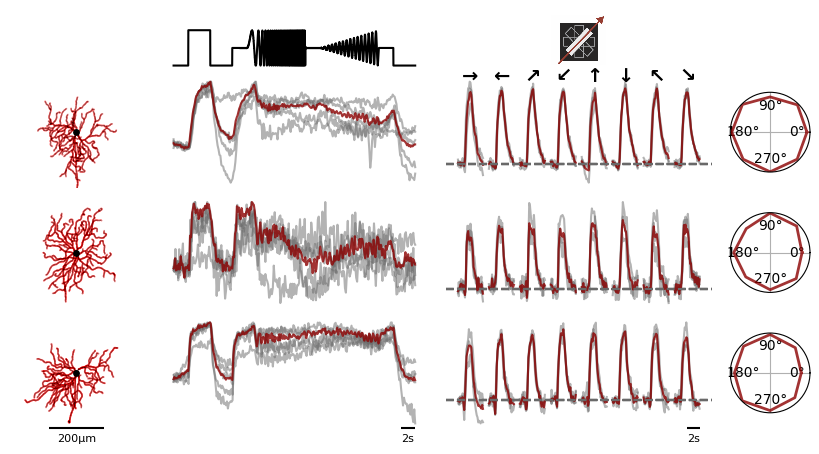

In [115]:
from matplotlib.transforms import Bbox
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

df = add_skels(df_pixon)

fig, axs = plt.subplots(
    len(df) + 1, 4,
    figsize=(8, (len(df) + 1) * 1.0),
    width_ratios=(1, 2, 2, 0.6), 
    gridspec_kw=dict(
        wspace=0.1, hspace=0.1,
        height_ratios=[0.35] + [1.0]*len(df)
    ),
)

for ax in axs[0, :]:
    ax.set_axis_off()

for r in range(1, len(df) + 1):
    gs = axs[r, -1].get_subplotspec()
    axs[r, -1].remove()
    axs[r, -1] = fig.add_subplot(gs, projection='polar')

for i, (seg_id, row) in enumerate(df.iterrows()):
    r = i + 1
    plot_morph(ax=axs[r, 0], row=row)
    plot_chirp(ax=axs[r, 1], row=row)
    plot_bar(ax=axs[r, 2], row=row, annotate_dirs=(i == 0))
    plot_bar_dir(ax=axs[r, 3], row=row)

for ax in axs[1:, :-1].flat:
    ax.set(xlabel=None, ylabel=None, xticks=[], yticks=[])
    ax.axis('off')

# format polar column
for ax in axs[1:, -1].flat:
    ax.set(xlabel=None, ylabel=None,
           xticks=np.deg2rad([0, 90, 180, 270]),
           yticks=[], ylim=(0, None))

#  add stimuli
ax = axs[0, 1]
ax.set_axis_off()
#chirp_zoom = 0.10   
#chirp_pos  = (0.5, 0.35)
#ab_chirp = AnnotationBbox(
#    OffsetImage(chirp_img, zoom=chirp_zoom, interpolation='nearest'),
#    chirp_pos, xycoords='axes fraction',
#    frameon=False, box_alignment=(0.5, 0.5))
#ax.add_artist(ab_chirp)
axs[0,1].plot(chirp_stimulus, color='k',lw=1.5)

ax = axs[0, 2]
ax.set_axis_off()
mb_zoom = 0.08      
mb_pos  = (0.5, 0.7)
ab_mb = AnnotationBbox(
    OffsetImage(mb_img, zoom=mb_zoom, interpolation='nearest'),
    mb_pos, xycoords='axes fraction',
    frameon=False, box_alignment=(0.5, 0.5))
ax.add_artist(ab_mb)

# scale bar
draw_scale_bar(axs[3,0], length_data=200, label="200µm", where="lower center", y_frac=0.0)
draw_scale_bar(axs[3,1], length_data=2, label="2s", where="lower right", y_frac=0.0, x_pad_axes=0.045)
draw_scale_bar(axs[3,2], length_data=2, label="2s", where="lower right", y_frac=0.0, x_pad_axes=0.045)


# make chirp plots smaller in height
shrink_y = 0.75
y_shift = 0.0
targets = []
for r in (1, 2, 3):
    if r <= len(df):  # since row 0 is the header
        targets.append(axs[r, 1])
for ax in targets:
    box = ax.get_position()          # figure coordinates
    cx = 0.5 * (box.x0 + box.x1)
    cy = 0.5 * (box.y0 + box.y1)
    w  = box.width
    h  = box.height * shrink_y
    new_box = Bbox.from_bounds(cx - w/2, cy - h/2 + y_shift, w, h)
    ax.set_position(new_box)

plt.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0.0, hspace=0.0)

In [105]:
def plot_morph(ax, row):
    prev = plt.gca()
    try:
        plt.sca(ax)  # make `ax` current
        sk.plot.projection(row.skel, ax=ax, plane='xy')
        sx, sy, sz = row.skel.soma.center
        ax.set_xlim(sx - 200, sx + 200)
        ax.set_ylim(sy - 200, sy + 200)
    finally:
        plt.sca(prev)  # restore previous axes
import numpy as np

MB_DIRS        = (0, 180, 45, 225, 90, 270, 135, 315)
MB_DIRS_SYMBOLS = ('→','←','↗','↙','↑','↓','↖','↘')

def plot_bar_block(ax, row, i, show_symbol=True):
    """
    Plot ONE direction block (index i: 0..7) on the given Cartesian axes.
    Matches your original styling.
    """
    snippets = row['bar_snippets'][:, np.array([0, 8, 16]) + i]
    time = (np.arange(0, snippets.shape[0]) + (snippets.shape[0] * 1.2 * i)) * row['bar_snippets_dt']

    # traces
    for trace in snippets.T:
        ax.plot(time, trace, color='dimgray', alpha=0.5)
    # mean
    ax.plot(time, np.mean(snippets, axis=1), color='darkred', alpha=0.8)
    ax.axhline(0, c='dimgray', ls='--')

    # label
    if show_symbol:
        x = time[0] + 0.5 * (time[-1] - time[0])
        y_max = np.max(row['bar_snippets'])
        y = y_max + 0.15 * (np.max(row['bar_snippets']) - np.min(row['bar_snippets']))  # relative offset
        ax.text(
            x, y, MB_DIRS_SYMBOLS[i],
            ha='center', va='top',
            fontsize=14,
            fontweight='bold'
        )

    # clean look (like your grid cells)
    ax.set(xlabel=None, ylabel=None, xticks=[], yticks=[])
    ax.axis('off')


def plot_bar_split(ax_map, row, labels=('C','D','E','F','H','I','J','K')):
    """
    Map the 8 direction blocks onto named axes (subplot_mosaic) or a dict of axes.
    ax_map: dict-like, e.g. axs['C'] -> Axes
    """
    # consistent y limits across all panels so heights match
    y_max = float(np.nanmax(row['bar_snippets']))
    y_min = float(np.nanmin(row['bar_snippets']))
    y_span = (y_max - y_min) if (y_max > y_min) else 1.0
    y_top = y_max + 0.15 * y_span

    for i, lab in enumerate(labels):
        ax = ax_map[lab]
        plot_bar_block(ax, row, i, show_symbol=True)
        # freeze consistent y-range
        ax.set_ylim(y_min, y_top)

def plot_bar_split(ax_map, row, labels=('C','D','E','F','H','I','J','K'),
                   dir_idx_order=(0,1,2,3,4,5,6,7)):
    """
    Plot the 8 direction blocks into named axes in a *specified* order.
    dir_idx_order: which data block (0..7) goes to each label, same length as labels.
    """
    y_max = float(np.nanmax(row['bar_snippets']))
    y_min = float(np.nanmin(row['bar_snippets']))
    y_span = (y_max - y_min) if (y_max > y_min) else 1.0
    y_top = y_max + 0.15 * y_span

    for lab, idx in zip(labels, dir_idx_order):
        ax = ax_map[lab]
        plot_bar_block(ax, row, idx, show_symbol=True)
        ax.set_ylim(y_min, y_top)

In [106]:
import h5py

try:
    with h5py.File("Z:/Resources/Stimulus/chirp.h5", "r") as f:
        chirp_stimulus = f['stimulusarray'][:].T.astype(int)
    chirp_stimulus = np.append(chirp_stimulus, np.full(1000, chirp_stimulus[-1]))
except:
    chirp_stimulus = np.ones(32988).astype(int)

## sON alpha

C:\Users\Dominic Gonschorek\Documents\GitHub\eyewire2-functional-analysis\.venv\Lib\site-packages\skeliner\plot\vis2d.py:625: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


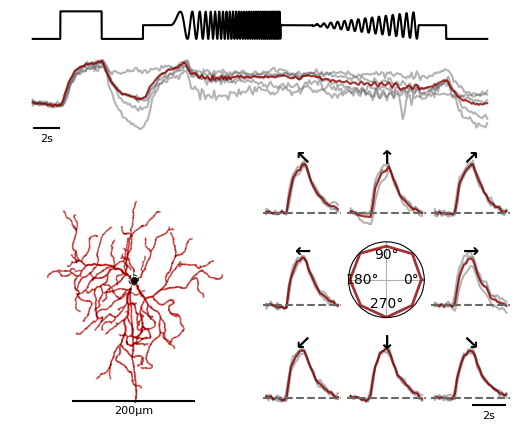

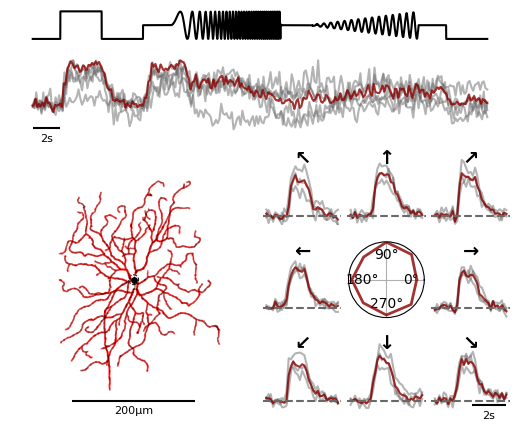

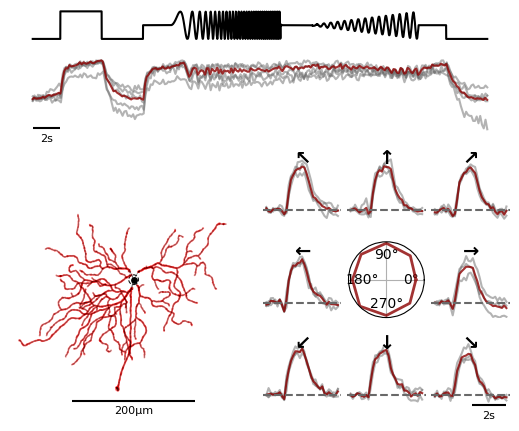

In [166]:
df = add_skels(df_son)

for i, (seg_id, row) in enumerate(df.iterrows()):
    r = i + 1

    fig, ax = plt.subplot_mosaic(
        """
        XXXXXX
        AAAAAA
        BBBCDE
        BBBFGH
        BBBIJK
        """,  
        figsize=(5, 4),
        gridspec_kw=dict(
            hspace=0.25, wspace=0.07, height_ratios=[0.4, 1, 1, 1, 1]),)
    
    plot_morph(ax=ax['B'], row=row)
    plot_chirp(ax=ax['A'], row=row)
    plot_bar_dir(ax=ax['G'], row=row)
    ax['G'].set(xlabel=None, ylabel=None, xticks=np.deg2rad([0, 90, 180, 270]), yticks=[], ylim=(0, None))
    
    
    MB_DIRS = (0, 180, 45, 225, 90, 270, 135, 315)  # your data order
    desired_deg = [0, 45, 90, 135, 180, 225, 270, 315]
    dir_idx_order = [MB_DIRS.index(d) for d in desired_deg]
    
    plot_bar_split(ax, row, labels=('C','D','E','F','H','I','J','K'), dir_idx_order=([6, 4, 2, 1, 0, 3, 5, 7]))
    
    gs = ax['G'].get_subplotspec()
    ax['G'].remove()
    ax['G'] = fig.add_subplot(gs, projection='polar')
    plot_bar_dir(ax=ax['G'], row=row)
    ax['G'].set(xlabel=None, ylabel=None, xticks=np.deg2rad([0, 90, 180, 270]), yticks=[], ylim=(0, None))
    
    ax['X'].plot(chirp_stimulus, color='k',lw=1.5)

    # remove axes
    for i in ['A','B','C','D','E','F','H','I','J','K','X']:
        ax[i].set(xlabel=None, ylabel=None, xticks=[], yticks=[])
        ax[i].axis('off')

    # scale bar
    draw_scale_bar(ax['B'], length_data=200, label="200µm", where="lower center", y_frac=0.01)
    draw_scale_bar(ax['A'], length_data=2, label="2s", where="lower left", y_frac=0.06, x_pad_axes=0.045)
    draw_scale_bar(ax['K'], length_data=2, label="2s", where="lower right", y_frac=0.06, x_pad_axes=0.045)
    #ax['B'].set_ylim(70,400)
    
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0, hspace=0.0)
    plt.savefig(os.path.join(fig2_dir, 'sON_examples_'+str(r)+'.png'), dpi=600)
    plt.savefig(os.path.join(fig2_dir, 'sON_examples_'+str(r)+'.svg'), dpi=600)

## PixON

C:\Users\Dominic Gonschorek\Documents\GitHub\eyewire2-functional-analysis\.venv\Lib\site-packages\skeliner\plot\vis2d.py:625: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


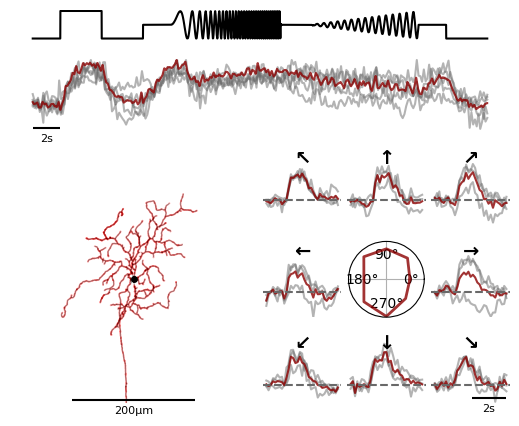

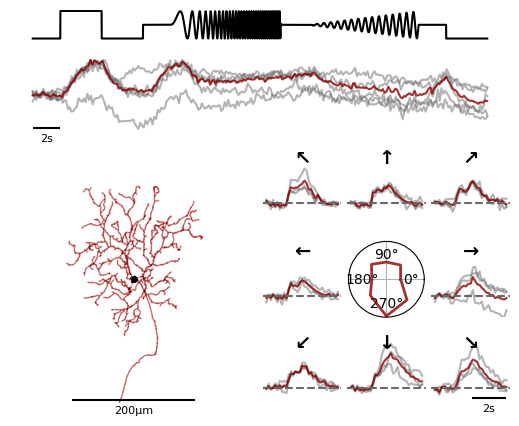

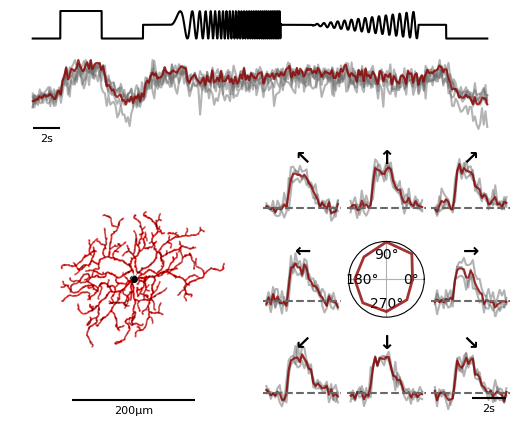

In [163]:
df = add_skels(df_pixon)

for i, (seg_id, row) in enumerate(df.iterrows()):
    r = i + 1

    fig, ax = plt.subplot_mosaic(
        """
        XXXXXX
        AAAAAA
        BBBCDE
        BBBFGH
        BBBIJK
        """,  
        figsize=(5, 4),
        gridspec_kw=dict(
            hspace=0.25, wspace=0.07, height_ratios=[0.4, 1, 1, 1, 1]),)
    
    plot_morph(ax=ax['B'], row=row)
    plot_chirp(ax=ax['A'], row=row)
    plot_bar_dir(ax=ax['G'], row=row)
    ax['G'].set(xlabel=None, ylabel=None, xticks=np.deg2rad([0, 90, 180, 270]), yticks=[], ylim=(0, None))
    
    
    MB_DIRS = (0, 180, 45, 225, 90, 270, 135, 315)  # your data order
    desired_deg = [0, 45, 90, 135, 180, 225, 270, 315]
    dir_idx_order = [MB_DIRS.index(d) for d in desired_deg]
    
    plot_bar_split(ax, row, labels=('C','D','E','F','H','I','J','K'), dir_idx_order=([6, 4, 2, 1, 0, 3, 5, 7]))
    
    gs = ax['G'].get_subplotspec()
    ax['G'].remove()
    ax['G'] = fig.add_subplot(gs, projection='polar')
    plot_bar_dir(ax=ax['G'], row=row)
    ax['G'].set(xlabel=None, ylabel=None, xticks=np.deg2rad([0, 90, 180, 270]), yticks=[], ylim=(0, None))
    
    ax['X'].plot(chirp_stimulus, color='k',lw=1.5)

    # remove axes
    for i in ['A','B','C','D','E','F','H','I','J','K','X']:
        ax[i].set(xlabel=None, ylabel=None, xticks=[], yticks=[])
        ax[i].axis('off')

    # scale bar
    draw_scale_bar(ax['B'], length_data=200, label="200µm", where="lower center", y_frac=0.01)
    draw_scale_bar(ax['A'], length_data=2, label="2s", where="lower left", y_frac=0.06, x_pad_axes=0.045)
    draw_scale_bar(ax['K'], length_data=2, label="2s", where="lower right", y_frac=0.15, x_pad_axes=0.045)
    #ax['B'].set_ylim(70,400)
    
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0, hspace=0.0)
    plt.savefig(os.path.join(fig2_dir, 'pixon_examples_'+str(r)+'.png'), dpi=600)
    plt.savefig(os.path.join(fig2_dir, 'pixon_examples_'+str(r)+'.svg'), dpi=600)

## UHD

C:\Users\Dominic Gonschorek\Documents\GitHub\eyewire2-functional-analysis\.venv\Lib\site-packages\skeliner\plot\vis2d.py:625: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


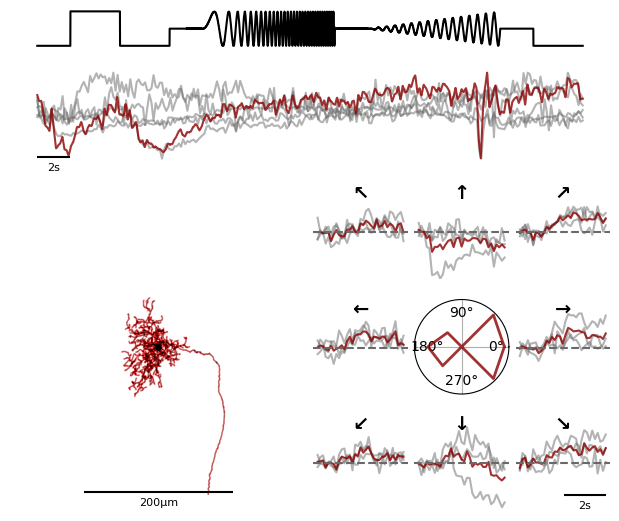

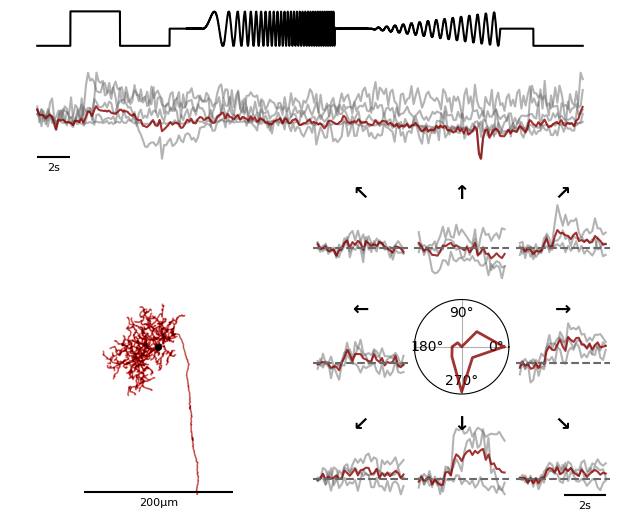

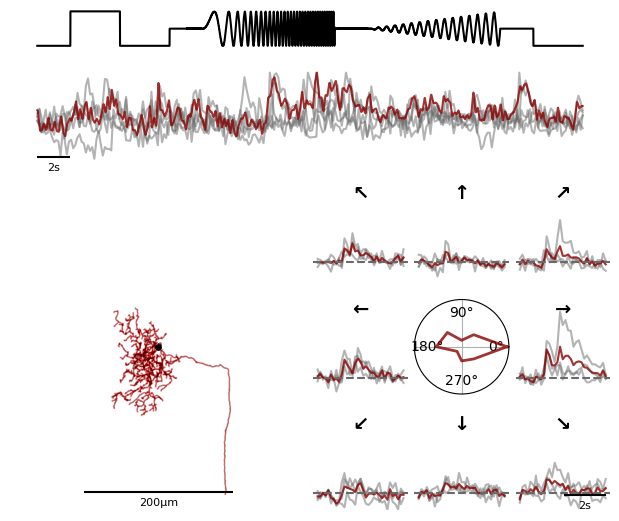

In [164]:
df = add_skels(df_uhd)

for i, (seg_id, row) in enumerate(df.iterrows()):
    r = i + 1

    fig, ax = plt.subplot_mosaic(
        """
        XXXXXX
        AAAAAA
        BBBCDE
        BBBFGH
        BBBIJK
        """,  
        figsize=(6,5),
        gridspec_kw=dict(
            hspace=0.25, wspace=0.07, height_ratios=[0.4, 1, 1, 1, 1]),)
    
    plot_morph(ax=ax['B'], row=row)
    plot_chirp(ax=ax['A'], row=row)
    plot_bar_dir(ax=ax['G'], row=row)
    ax['G'].set(xlabel=None, ylabel=None, xticks=np.deg2rad([0, 90, 180, 270]), yticks=[], ylim=(0, None))
    
    
    MB_DIRS = (0, 180, 45, 225, 90, 270, 135, 315)  # your data order
    desired_deg = [0, 45, 90, 135, 180, 225, 270, 315]
    dir_idx_order = [MB_DIRS.index(d) for d in desired_deg]
    
    plot_bar_split(ax, row, labels=('C','D','E','F','H','I','J','K'), dir_idx_order=([6, 4, 2, 1, 0, 3, 5, 7]))
    
    gs = ax['G'].get_subplotspec()
    ax['G'].remove()
    ax['G'] = fig.add_subplot(gs, projection='polar')
    plot_bar_dir(ax=ax['G'], row=row)
    ax['G'].set(xlabel=None, ylabel=None, xticks=np.deg2rad([0, 90, 180, 270]), yticks=[], ylim=(0, None))
    
    ax['X'].plot(chirp_stimulus, color='k',lw=1.5)

    # remove axes
    for i in ['A','B','C','D','E','F','H','I','J','K','X']:
        ax[i].set(xlabel=None, ylabel=None, xticks=[], yticks=[])
        ax[i].axis('off')

    # scale bar
    draw_scale_bar(ax['B'], length_data=200, label="200µm", where="lower center", y_frac=0.01)
    draw_scale_bar(ax['A'], length_data=2, label="2s", where="lower left", y_frac=0.06, x_pad_axes=0.045)
    draw_scale_bar(ax['K'], length_data=2, label="2s", where="lower right", y_frac=0.15, x_pad_axes=0.045)
    #ax['B'].set_ylim(70,400)
    
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0, hspace=0.0)
    plt.savefig(os.path.join(fig2_dir, 'uhd_examples_'+str(r)+'.png'), dpi=600)
    plt.savefig(os.path.join(fig2_dir, 'uhd_examples_'+str(r)+'.svg'), dpi=600)